# Part III: Non-Linear Least Squares
## The Gauss-Newton Algorithm

In many real-world applications (like fitting a model to data), our objective function isn't just a generic curve. It is specifically a **Sum of Squared Residuals**. 

We want to find parameters $x$ that minimize the error between our model's predictions $f(t_i; x)$ and the actual observed data $y_i$. We define the residual for a single data point as:
$$r_i(x) = f(t_i; x) - y_i$$

Our total objective function is the sum of these squared errors:
$$F(x) = \frac{1}{2} \sum_{i=1}^M r_i(x)^2 = \frac{1}{2} \| r(x) \|^2$$

### The Magic of the Jacobian
If we tried to use standard Newton's Method here, we would need to compute the $N \times N$ Hessian matrix (second derivatives). For complex models, calculating second derivatives is an absolute nightmare.

**Gauss-Newton** provides a brilliant shortcut. Because of the specific "squared sum" structure of our objective function, we can *approximate* the Hessian using only the **Jacobian matrix** ($J$)—the matrix of *first* derivatives of the residuals!

$$J_{i,j} = \frac{\partial r_i}{\partial x_j}$$

The algorithm approximates the Hessian as $H \approx J^T J$ and the exact gradient as $g = J^T r$. 

By substituting these into Newton's update rule, we get the elegant Gauss-Newton step:
$$x_{k+1} = x_k - (J^T J)^{-1} J^T r(x_k)$$

**The Advantage:** We get the blazing-fast, second-order convergence of Newton's Method without ever having to calculate a single second derivative!

Running Gauss-Newton Algorithm...
Converged successfully after 8 iterations.

--- Parameter Results ---
True Parameters:    [ 2.  -0.5 -1.  -1.5]
Solved Parameters:  [ 2.  -0.5 -1.  -1.5]


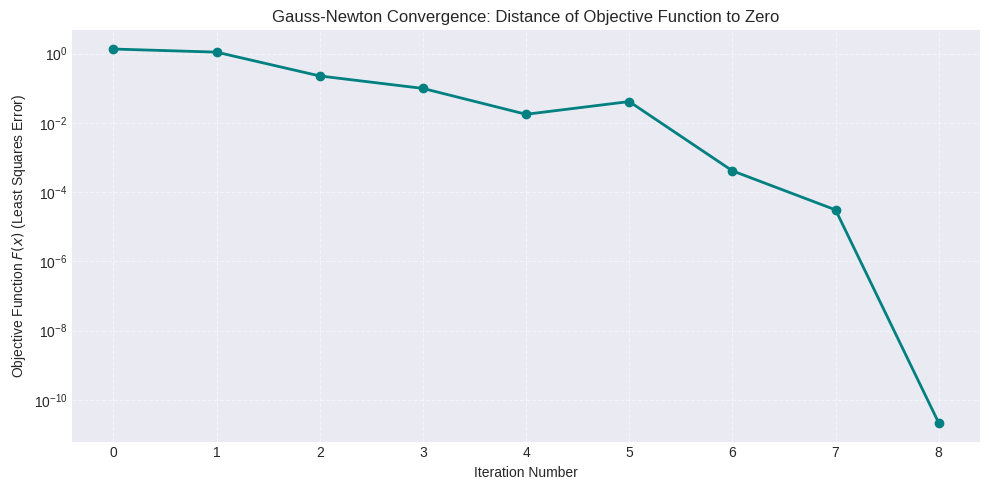

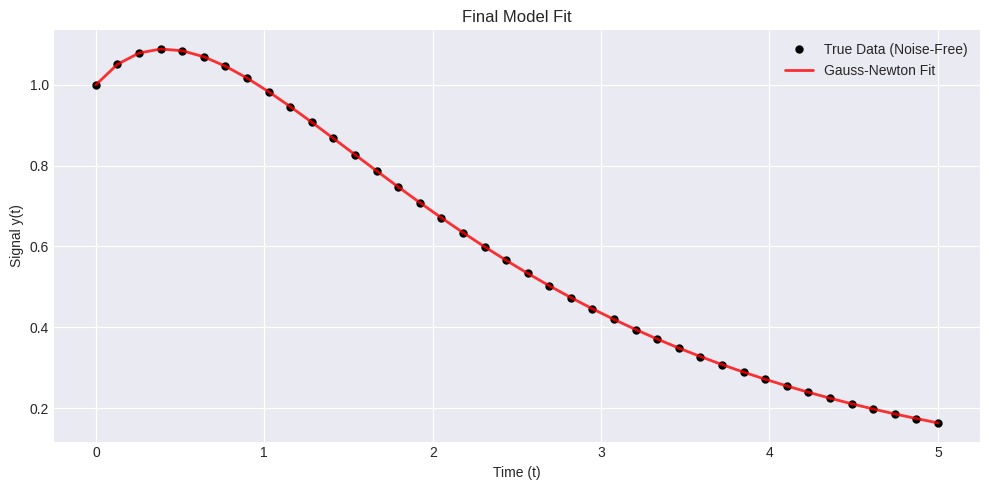

In [2]:
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-darkgrid')
np.set_printoptions(precision=4, suppress=True)

# ---------------------------------------------------------
# 1. Setup the Non-Linear Least Squares Problem
# ---------------------------------------------------------
# Let's create a synthetic dataset. We want to fit a double exponential decay model:
# f(t; x) = A * exp(lambda_1 * t) + B * exp(lambda_2 * t)
# Our parameter vector is x = [A, lambda_1, B, lambda_2]

# Generate synthetic time data
t = np.linspace(0, 5, 40)

# True parameters (unknown to the algorithm)
x_true = np.array([2.0, -0.5, -1.0, -1.5])

# Generate perfect, noise-free observations
# Since it's noise-free, the true minimum of the objective function is exactly 0.0
y_obs = x_true[0] * np.exp(x_true[1] * t) + x_true[2] * np.exp(x_true[3] * t)

def compute_residuals(x):
    """Calculates the vector of residuals r(x)."""
    A, lam1, B, lam2 = x
    model_predictions = A * np.exp(lam1 * t) + B * np.exp(lam2 * t)
    return model_predictions - y_obs

def compute_jacobian(x):
    """Calculates the M x N Jacobian matrix of the residuals."""
    A, lam1, B, lam2 = x
    J = np.zeros((len(t), len(x)))
    
    # Partial derivatives of the residual with respect to each parameter
    J[:, 0] = np.exp(lam1 * t)               # dr/dA
    J[:, 1] = A * t * np.exp(lam1 * t)       # dr/d(lambda_1)
    J[:, 2] = np.exp(lam2 * t)               # dr/dB
    J[:, 3] = B * t * np.exp(lam2 * t)       # dr/d(lambda_2)
    
    return J

# ---------------------------------------------------------
# 2. The Gauss-Newton Algorithm
# ---------------------------------------------------------
def gauss_newton(x0, max_iter=50, tol=1e-8):
    """
    Performs the Gauss-Newton optimization for least squares.
    """
    x = np.array(x0, dtype=float)
    
    # Track the history of the objective function: F(x) = 0.5 * ||r(x)||^2
    # Because our data is noise-free, F(x) is exactly the "distance to zero"
    objective_history = []
    
    for i in range(max_iter):
        # 1. Evaluate Residuals and Jacobian
        r = compute_residuals(x)
        J = compute_jacobian(x)
        
        # Calculate current objective function value
        cost = 0.5 * np.sum(r**2)
        objective_history.append(cost)
        
        # Check convergence based on the cost
        if cost < tol:
            print(f"Converged successfully after {i} iterations.")
            break
            
        # 2. Compute the Gauss-Newton step: delta_x = - (J^T J)^-1 J^T r
        # We solve the linear system (J^T J) delta_x = -J^T r for numerical stability
        JTJ = J.T @ J
        JTr = J.T @ r
        
        try:
            delta_x = np.linalg.solve(JTJ, -JTr)
        except np.linalg.LinAlgError:
            print("Jacobian matrix became singular. Halting.")
            break
            
        # 3. Update parameters
        x = x + delta_x
        
    else:
        print(f"Reached max iterations ({max_iter}) without full convergence.")
        
    return x, np.array(objective_history)

# ---------------------------------------------------------
# 3. Execution and Visualization
# ---------------------------------------------------------
# Initial guess (Must be reasonably close, Gauss-Newton is sensitive to bad initializations)
x_start = np.array([1.0, -0.2, -0.5, -1.0])

print("Running Gauss-Newton Algorithm...")
x_final, cost_history = gauss_newton(x_start)

print("\n--- Parameter Results ---")
print(f"True Parameters:    {x_true}")
print(f"Solved Parameters:  {x_final}")

# Plotting the Convergence
plt.figure(figsize=(10, 5))
plt.plot(cost_history, 'o-', color='teal', linewidth=2, markersize=6)

# We use a log scale because Gauss-Newton convergence is incredibly fast near the minimum
plt.yscale('log')
plt.xlabel('Iteration Number')
plt.ylabel('Objective Function $F(x)$ (Least Squares Error)')
plt.title('Gauss-Newton Convergence: Distance of Objective Function to Zero')
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.tight_layout()
plt.show()

# Optional: Plot the curve fit
plt.figure(figsize=(10, 5))
plt.plot(t, y_obs, 'ko', label='True Data (Noise-Free)', markersize=5)
plt.plot(t, x_final[0]*np.exp(x_final[1]*t) + x_final[2]*np.exp(x_final[3]*t), 
         'r-', label='Gauss-Newton Fit', linewidth=2, alpha=0.8)
plt.xlabel('Time (t)')
plt.ylabel('Signal y(t)')
plt.title('Final Model Fit')
plt.legend()
plt.tight_layout()
plt.show()

## Application: Modeling World Population Growth

Let's apply Non-Linear Least Squares to a real-world dataset: **Global Human Population**. 

We will test two competing mathematical models against historical data from 1950 to 2020, and then project them forward to the year 2100.

**1. The Exponential Model (Malthusian Growth)**
Assumes population grows at a constant rate proportional to its current size.
$$P(t) = P_0 e^{r(t - t_{start})}$$
*   $P_0$: Initial population
*   $r$: Continuous growth rate

**2. The Logistic Model (Verhulst Growth)**
Assumes population growth slows down as it approaches a maximum environmental "carrying capacity."
$$P(t) = \frac{L}{1 + e^{-k(t - t_0)}}$$
*   $L$: Carrying capacity (Maximum theoretical population)
*   $k$: Logistic growth rate (steepness of the curve)
*   $t_0$: The inflection point year (when growth rate is highest)

To solve this efficiently, we will use `scipy.optimize.curve_fit`, which uses the Levenberg-Marquardt algorithm (a highly robust upgrade to the Gauss-Newton method we just built!).

--- Dense Data Optimization Results ---
Exponential Fit: P0 = 2.71 billion, Rate = 0.0159
Logistic Fit: Carrying Capacity (L) = 12.84 billion
              Inflection Year (t0) = 2003


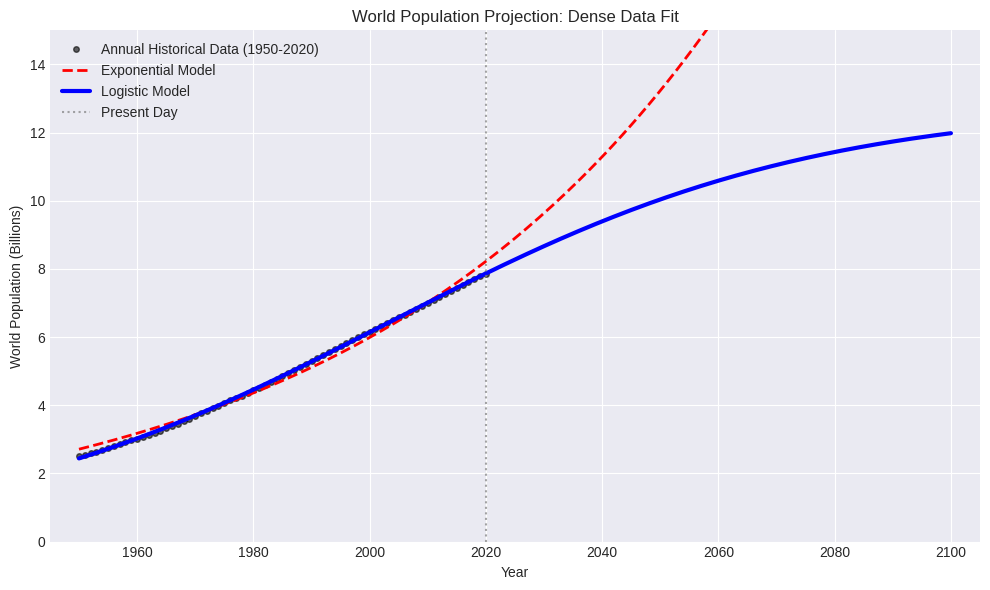

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# ---------------------------------------------------------
# 1. The Dense Data (Annual World Population: 1950 - 2020)
# ---------------------------------------------------------
years = np.arange(1950, 2021)

# Historical world population in billions (UN / Macrotrends estimates)
pop = np.array([
    2.50, 2.54, 2.59, 2.64, 2.69, 2.75, 2.80, 2.86, 2.92, 2.97, # 1950-1959
    3.02, 3.06, 3.12, 3.18, 3.25, 3.32, 3.39, 3.46, 3.53, 3.60, # 1960-1969
    3.68, 3.76, 3.83, 3.91, 3.99, 4.06, 4.14, 4.21, 4.28, 4.36, # 1970-1979
    4.44, 4.52, 4.60, 4.68, 4.77, 4.85, 4.94, 5.03, 5.12, 5.21, # 1980-1989
    5.30, 5.39, 5.48, 5.56, 5.65, 5.74, 5.82, 5.91, 5.99, 6.08, # 1990-1999
    6.16, 6.25, 6.33, 6.41, 6.49, 6.58, 6.66, 6.74, 6.83, 6.92, # 2000-2009
    7.00, 7.09, 7.18, 7.27, 7.35, 7.44, 7.53, 7.61, 7.70, 7.78, # 2010-2019
    7.86                                                        # 2020
])

# Normalize the x-data (years) for numerical stability
t_data = years - 1950

# ---------------------------------------------------------
# 2. Define the Models
# ---------------------------------------------------------
def exponential_model(t, P0, r):
    """Exponential growth model."""
    return P0 * np.exp(r * t)

def logistic_model(t, L, k, t0):
    """Logistic growth model."""
    return L / (1 + np.exp(-k * (t - t0)))

# ---------------------------------------------------------
# 3. Fit the Models using Non-Linear Least Squares
# ---------------------------------------------------------
# Fit Exponential (Initial guess: 2.5 billion start, 2% growth)
exp_opt, exp_cov = curve_fit(exponential_model, t_data, pop, p0=[2.5, 0.02])

# Fit Logistic (Initial guess: Capacity=12, rate=3%, inflection=1990)
log_opt, log_cov = curve_fit(logistic_model, t_data, pop, p0=[12.0, 0.03, 40.0])

print("--- Dense Data Optimization Results ---")
print(f"Exponential Fit: P0 = {exp_opt[0]:.2f} billion, Rate = {exp_opt[1]:.4f}")
print(f"Logistic Fit: Carrying Capacity (L) = {log_opt[0]:.2f} billion")
print(f"              Inflection Year (t0) = {1950 + log_opt[2]:.0f}")

# ---------------------------------------------------------
# 4. Projection and Visualization
# ---------------------------------------------------------
future_years = np.linspace(1950, 2100, 200)
t_future = future_years - 1950

pop_exp_pred = exponential_model(t_future, *exp_opt)
pop_log_pred = logistic_model(t_future, *log_opt)

plt.figure(figsize=(10, 6))

# Plot historical dense data
plt.plot(years, pop, 'k.', markersize=8, alpha=0.6, label='Annual Historical Data (1950-2020)')

# Plot projections
plt.plot(future_years, pop_exp_pred, 'r--', linewidth=2, label='Exponential Model')
plt.plot(future_years, pop_log_pred, 'b-', linewidth=3, label='Logistic Model')

# Formatting
plt.axvline(2020, color='gray', linestyle=':', alpha=0.7, label='Present Day')
plt.ylim(0, 15)
plt.xlim(1945, 2105)
plt.xlabel('Year')
plt.ylabel('World Population (Billions)')
plt.title('World Population Projection: Dense Data Fit')
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

## Application 2: 3D GPS Localization (Trilateration)

Imagine you are a GPS receiver. You don't know your 3D coordinates $(x, y, z)$. However, you can communicate with $M$ satellites in orbit. 
For each satellite $i$, you know:
1. Its exact position: $(X_i, Y_i, Z_i)$
2. Your measured distance to it: $D_i$

If our guess for our current position is $P = (x, y, z)$, the theoretical distance to satellite $i$ is:
$$d_i(x,y,z) = \sqrt{(x - X_i)^2 + (y - Y_i)^2 + (z - Z_i)^2}$$

The residual (our error) for satellite $i$ is the difference between our theoretical distance and the actual measured distance:
$$r_i(x,y,z) = d_i(x,y,z) - D_i$$

Our objective is to find the $(x, y, z)$ coordinates that minimize the sum of squared residuals for all connected satellites:
$$F(x, y, z) = \frac{1}{2} \sum_{i=1}^M r_i(x,y,z)^2$$

### The Analytical Jacobian
To use Gauss-Newton, we need the Jacobian matrix $J$. The partial derivative of the residual with respect to $x$ (using the chain rule) is simply the distance along the x-axis divided by the total distance!
$$J_{i, 1} = \frac{\partial r_i}{\partial x} = \frac{x - X_i}{d_i(x,y,z)}$$
$$J_{i, 2} = \frac{\partial r_i}{\partial y} = \frac{y - Y_i}{d_i(x,y,z)}$$
$$J_{i, 3} = \frac{\partial r_i}{\partial z} = \frac{z - Z_i}{d_i(x,y,z)}$$

Let's implement this and watch the algorithm drop from an initial guess down to our exact location on Earth.

Booting GPS Receiver. Running Gauss-Newton...

GPS Lock acquired after 4 iterations.
True Position: [6371. 1500. 3000.]
Calculated:    [6371. 1500. 3000.]
Final Error:   0.000000 km


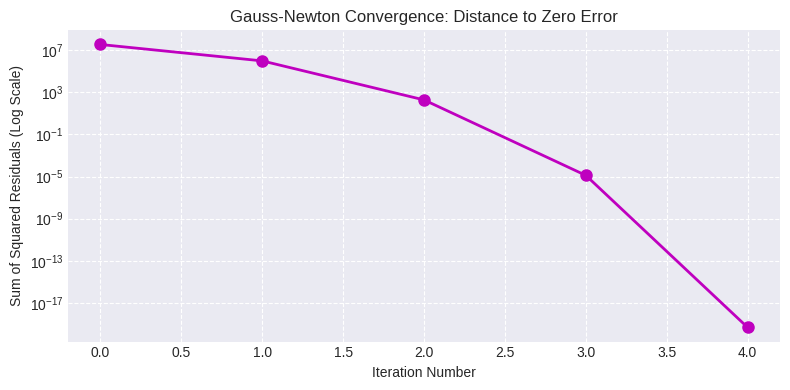

[[   0.        0.        0.    ]
 [6631.1356 1605.1935 2113.2578]
 [6365.4506 1497.1882 2986.9635]
 [6371.0014 1500.0007 2999.9968]
 [6371.     1500.     3000.    ]]


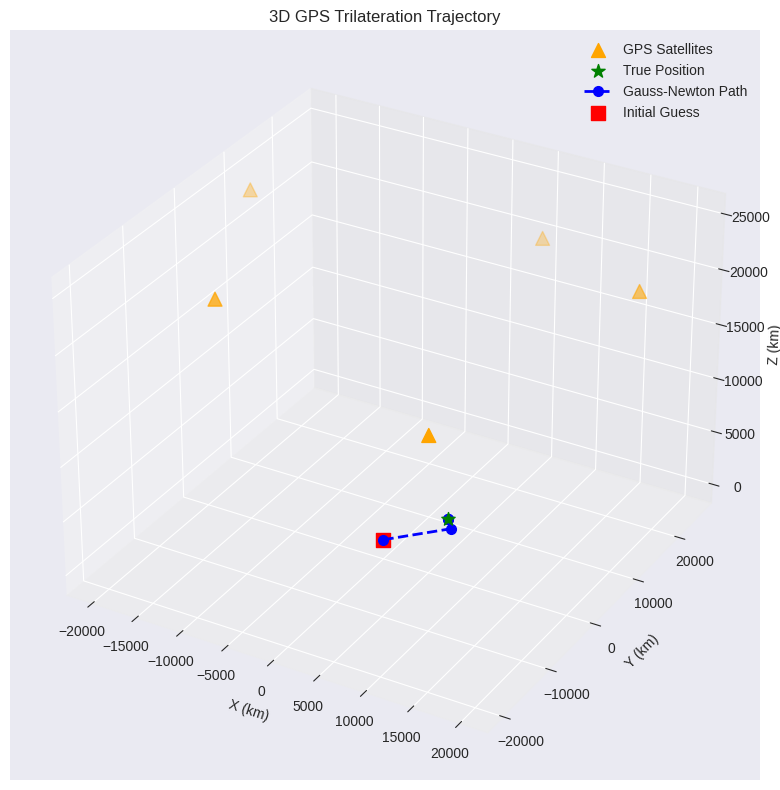

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# ---------------------------------------------------------
# 1. Setup the GPS Problem Environment
# ---------------------------------------------------------
# Define 5 satellites in 3D space [X, Y, Z] (e.g., thousands of km above Earth)
satellites = np.array([
    [20000, 15000, 22000],
    [-20000, 10000, 24000],
    [15000, -20000, 21000],
    [-10000, -15000, 25000],
    [5000, 25000, 20000]
])

# Our TRUE position (unknown to the algorithm)
true_position = np.array([6371.0, 1500.0, 3000.0]) # Roughly on Earth's surface

# Generate the exact distances from the true position to each satellite
measured_distances = np.linalg.norm(satellites - true_position, axis=1)

# ---------------------------------------------------------
# 2. Residuals and Jacobian Functions
# ---------------------------------------------------------
def gps_residuals(guess):
    """Calculates the difference between guessed distances and measured distances."""
    guessed_distances = np.linalg.norm(satellites - guess, axis=1)
    return guessed_distances - measured_distances

def gps_jacobian(guess):
    """Calculates the analytical Jacobian for the GPS trilateration problem."""
    J = np.zeros((len(satellites), 3))
    guessed_distances = np.linalg.norm(satellites - guess, axis=1)
    
    for i in range(len(satellites)):
        # Prevent division by zero if we guess exactly on a satellite
        dist = max(guessed_distances[i], 1e-10) 
        J[i, 0] = (guess[0] - satellites[i, 0]) / dist
        J[i, 1] = (guess[1] - satellites[i, 1]) / dist
        J[i, 2] = (guess[2] - satellites[i, 2]) / dist
        
    return J

# ---------------------------------------------------------
# 3. Gauss-Newton Algorithm for 3D Localization
# ---------------------------------------------------------
def gauss_newton_gps(guess_start, max_iter=20, tol=1e-8):
    guess = np.array(guess_start, dtype=float)
    
    cost_history = []
    path_history = [guess.copy()]
    
    for i in range(max_iter):
        r = gps_residuals(guess)
        J = gps_jacobian(guess)
        
        # Objective function F(x)
        cost = 0.5 * np.sum(r**2)
        cost_history.append(cost)
        
        if cost < tol:
            print(f"GPS Lock acquired after {i} iterations.")
            break
            
        # Gauss-Newton step
        JTJ = J.T @ J
        JTr = J.T @ r
        delta = np.linalg.solve(JTJ, -JTr)
        
        guess = guess + delta
        path_history.append(guess.copy())
        
    return np.array(path_history), cost_history

# ---------------------------------------------------------
# 4. Execution and Visualization
# ---------------------------------------------------------
# Initial guess (e.g., center of the Earth)
initial_guess = np.array([0.0, 0.0, 0.0])

print("Booting GPS Receiver. Running Gauss-Newton...\n")
path, cost_history = gauss_newton_gps(initial_guess)

print(f"True Position: {true_position}")
print(f"Calculated:    {path[-1]}")
print(f"Final Error:   {np.linalg.norm(path[-1] - true_position):.6f} km")

# --- Plot 1: Convergence ---
plt.figure(figsize=(8, 4))
plt.plot(cost_history, 'mo-', linewidth=2, markersize=8)
plt.yscale('log')
plt.xlabel('Iteration Number')
plt.ylabel('Sum of Squared Residuals (Log Scale)')
plt.title('Gauss-Newton Convergence: Distance to Zero Error')
plt.grid(True, which="both", ls="--")
plt.tight_layout()
plt.show()

# --- Plot 2: 3D Trajectory Visualization ---
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot Satellites
ax.scatter(satellites[:, 0], satellites[:, 1], satellites[:, 2], 
           c='orange', marker='^', s=100, label='GPS Satellites')

# Plot True Position
ax.scatter(true_position[0], true_position[1], true_position[2], 
           c='green', marker='*',s=100, label='True Position')

# Plot Algorithm Trajectory
print(path)
ax.plot(path[:, 0], path[:, 1], path[:, 2], 
        'b--o', linewidth=2, markersize=7, label='Gauss-Newton Path')

# Plot Initial Guess
ax.scatter(path[0, 0], path[0, 1], path[0, 2], 
           c='red', marker='s', s=100, label='Initial Guess')

ax.set_xlabel('X (km)')
ax.set_ylabel('Y (km)')
ax.set_zlabel('Z (km)')
ax.set_title('3D GPS Trilateration Trajectory')
ax.legend()
plt.tight_layout()
plt.show()